In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

df = pd.read_csv(r"house_prices_dataset.csv")

In [2]:

df.head(20)

,Area(SQM),Bedroom,Bathroom,Location,Price,Negotiable,Balcony,Electricity,Water,Gas,...,Private_Garden,Parking,Central(A/C)& heating,Pool,Type,Level,Furnished,Compound,Delivery_Date,Delivery_Term
0,125,3,2,Shatby,2200000,1,1,1,1,1,...,0,0,0,0,Apartment,10,0.0,NaN,Ready,Finished
1,120,4,1,Sidi Beshr,500000,0,0,1,1,1,...,0,0,0,0,Apartment,3,0.0,NaN,Ready,Finished
2,165,3,2,Sidi Beshr,1500000,1,1,1,1,1,...,0,0,0,0,Apartment,3,0.0,NaN,NaN,Finished
3,155,3,2,Cleopatra,1650000,0,0,0,0,0,...,0,0,0,0,Apartment,3,0.0,NaN,Ready,Finished
4,210,3,2,Smoha,2950000,0,0,0,0,0,...,0,0,0,0,Apartment,6,0.0,NaN,NaN,Finished
5,80,2,1,Miami,550000,0,0,0,1,0,...,0,0,0,0,Apartment,10+,0.0,NaN,soon,Finished
6,150,3,2,Al Hadrah,1100000,1,1,1,0,1,...,0,1,1,0,Apartment,1,0.0,NaN,Ready,Finished
7,160,3,2,Glim,2000080,0,1,1,1,1,...,0,0,0,0,Apartment,4,0.0,NaN,NaN,NaN
8,123,2,2,Smoha,2700000,0,0,0,0,0,...,0,0,0,0,Apartment,1,0.0,NaN,2023,Finished
9,65,2,1,Sidi Beshr,400000,0,0,1,1,1,...,0,0,0,0,Apartment,6,0.0,NaN,Ready,NaN


In [3]:
print("Shape:", df.shape)
print("\nInfo:")
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())

Shape: (8741, 25)

Info:
<class 'pandas.DataFrame'>
RangeIndex: 8741 entries, 0 to 8740
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Area(SQM)              8741 non-null   int64  
 1   Bedroom                8741 non-null   str    
 2   Bathroom               8741 non-null   str    
 3   Location               8741 non-null   str    
 4   Price                  8741 non-null   int64  
 5   Negotiable             8741 non-null   int64  
 6   Balcony                8741 non-null   int64  
 7   Electricity            8741 non-null   int64  
 8   Water                  8741 non-null   int64  
 9   Gas                    8741 non-null   int64  
 10  Landline               8741 non-null   int64  
 11  Elevator               8741 non-null   int64  
 12  Security               8741 non-null   int64  
 13  Built_in_Kitchen       8741 non-null   int64  
 14  Maids_Room             8741 non-null   int

In [4]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
cat_cols = df.select_dtypes(include=["object"]).columns
bool_cols = df.select_dtypes(include=["bool"]).columns

print("\nNumerical Columns:", num_cols)
print("\nCategorical Columns:", cat_cols)
print("\nBoolean Columns:", bool_cols)


Numerical Columns: Index(['Area(SQM)', 'Price', 'Negotiable', 'Balcony', 'Electricity', 'Water',
       'Gas', 'Landline', 'Elevator', 'Security', 'Built_in_Kitchen',
       'Maids_Room', 'Private_Garden', 'Parking', 'Central(A/C)& heating',
       'Pool', 'Furnished'],
      dtype='str')

Categorical Columns: Index(['Bedroom', 'Bathroom', 'Location', 'Type', 'Level', 'Compound',
       'Delivery_Date', 'Delivery_Term'],
      dtype='str')

Boolean Columns: Index([], dtype='str')


C:\Users\Compu House\AppData\Local\Temp\ipykernel_7012\3555786085.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=["object"]).columns


In [5]:
print("\nStatistical Summary:")
print(df.describe())


Statistical Summary:
         Area(SQM)         Price   Negotiable      Balcony  Electricity  \
count  8741.000000  8.741000e+03  8741.000000  8741.000000  8741.000000   
mean    140.820615  1.470502e+06     0.438051     0.607024     0.757922   
std      61.690883  2.083523e+06     0.496176     0.488439     0.428366   
min      10.000000  2.000000e+05     0.000000     0.000000     0.000000   
25%     100.000000  3.750000e+05     0.000000     0.000000     1.000000   
50%     125.000000  8.000000e+05     0.000000     1.000000     1.000000   
75%     160.000000  2.000000e+06     1.000000     1.000000     1.000000   
max     900.000000  8.000000e+07     1.000000     1.000000     1.000000   

             Water          Gas     Landline     Elevator     Security  \
count  8741.000000  8741.000000  8741.000000  8741.000000  8741.000000   
mean      0.742936     0.567784     0.398238     0.616749     0.486443   
std       0.437040     0.495412     0.489563     0.486207     0.499845   
min   

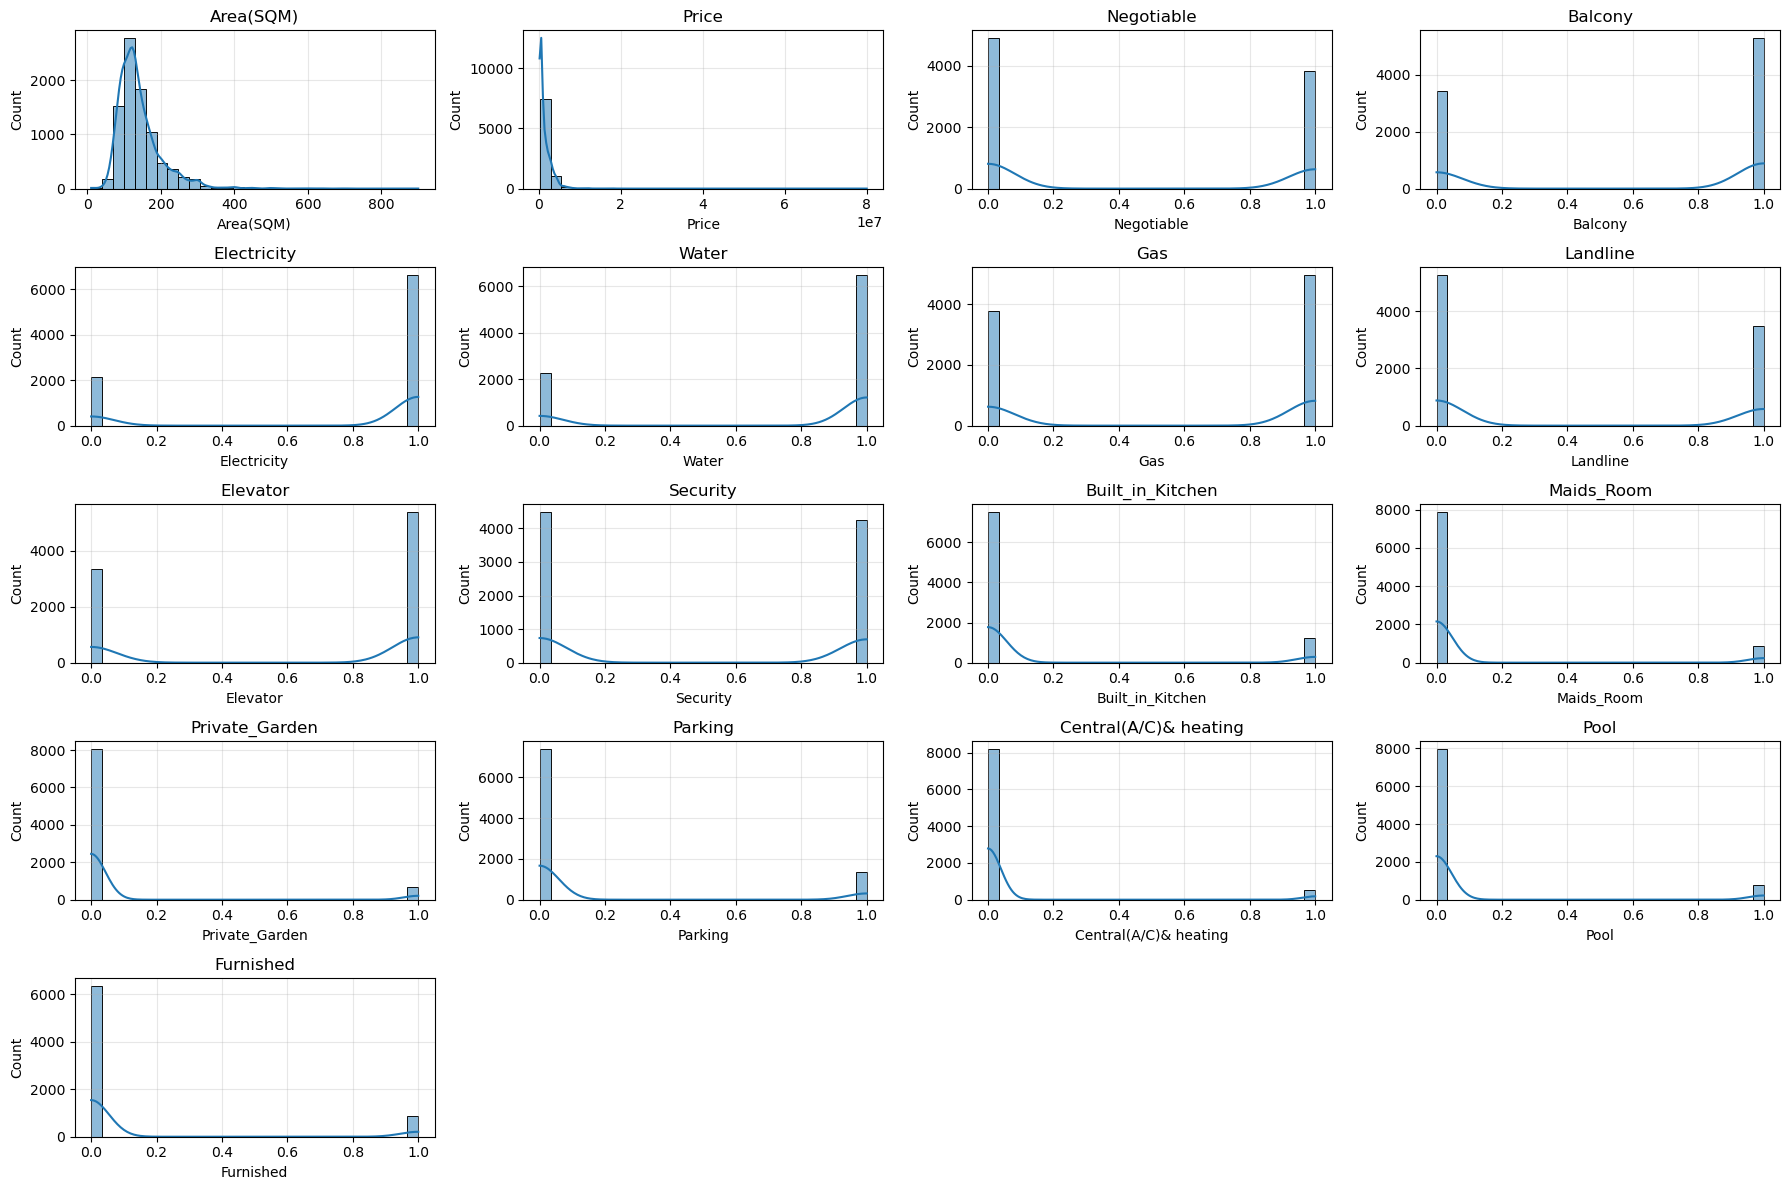

In [6]:
n_cols = 4
n_rows = math.ceil(len(num_cols) / n_cols)

plt.figure(figsize=(18, 12))
for i, col in enumerate(num_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)
    plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Distribution Analysis — Numerical Features (House Prices Dataset):**

- **Area(SQM):** Right-skewed; most properties are 100–200 SQM with a few outliers above 400 SQM.
- **Price:** Highly right-skewed (skewness ~12.9); most listings are below 2M EGP, with luxury properties up to 80M EGP.
- **Binary features** (Balcony, Electricity, Water, Gas, etc.): Concentrated at 0 or 1 as expected for binary indicators.
- **Negotiable:** ~44% of listings are negotiable.
- **Elevator & Security:** Present in majority of listings (~62% and ~49% respectively).
- **Premium amenities** (Pool, Private_Garden, Central A/C): Rare — means below 10%, indicating uncommon features in most listings.

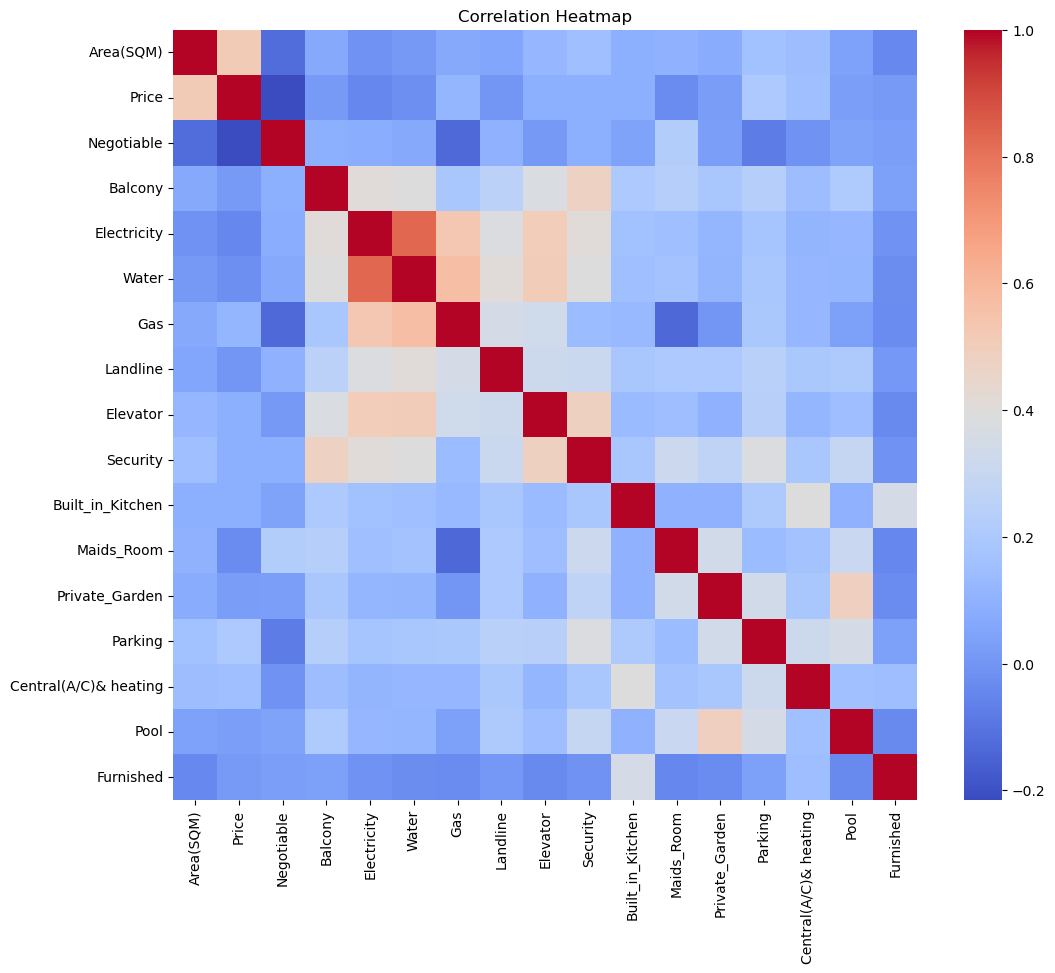

In [7]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap")
plt.show()

**Correlation Heatmap Analysis:**

- **Area(SQM) and Price** show a moderate positive correlation — larger apartments tend to cost more.
- **Utility features** (Electricity, Water, Gas) are highly correlated with each other, suggesting they appear together in the same listings.
- **Premium amenities** (Pool, Private_Garden, Maids_Room, Parking) show moderate positive correlations with Price, indicating higher-end properties.
- **Negotiable** shows a slight negative correlation with Price — cheaper listings are more likely to be negotiable.
- No single feature dominates price prediction; location and property type (in categorical columns) likely play important roles.

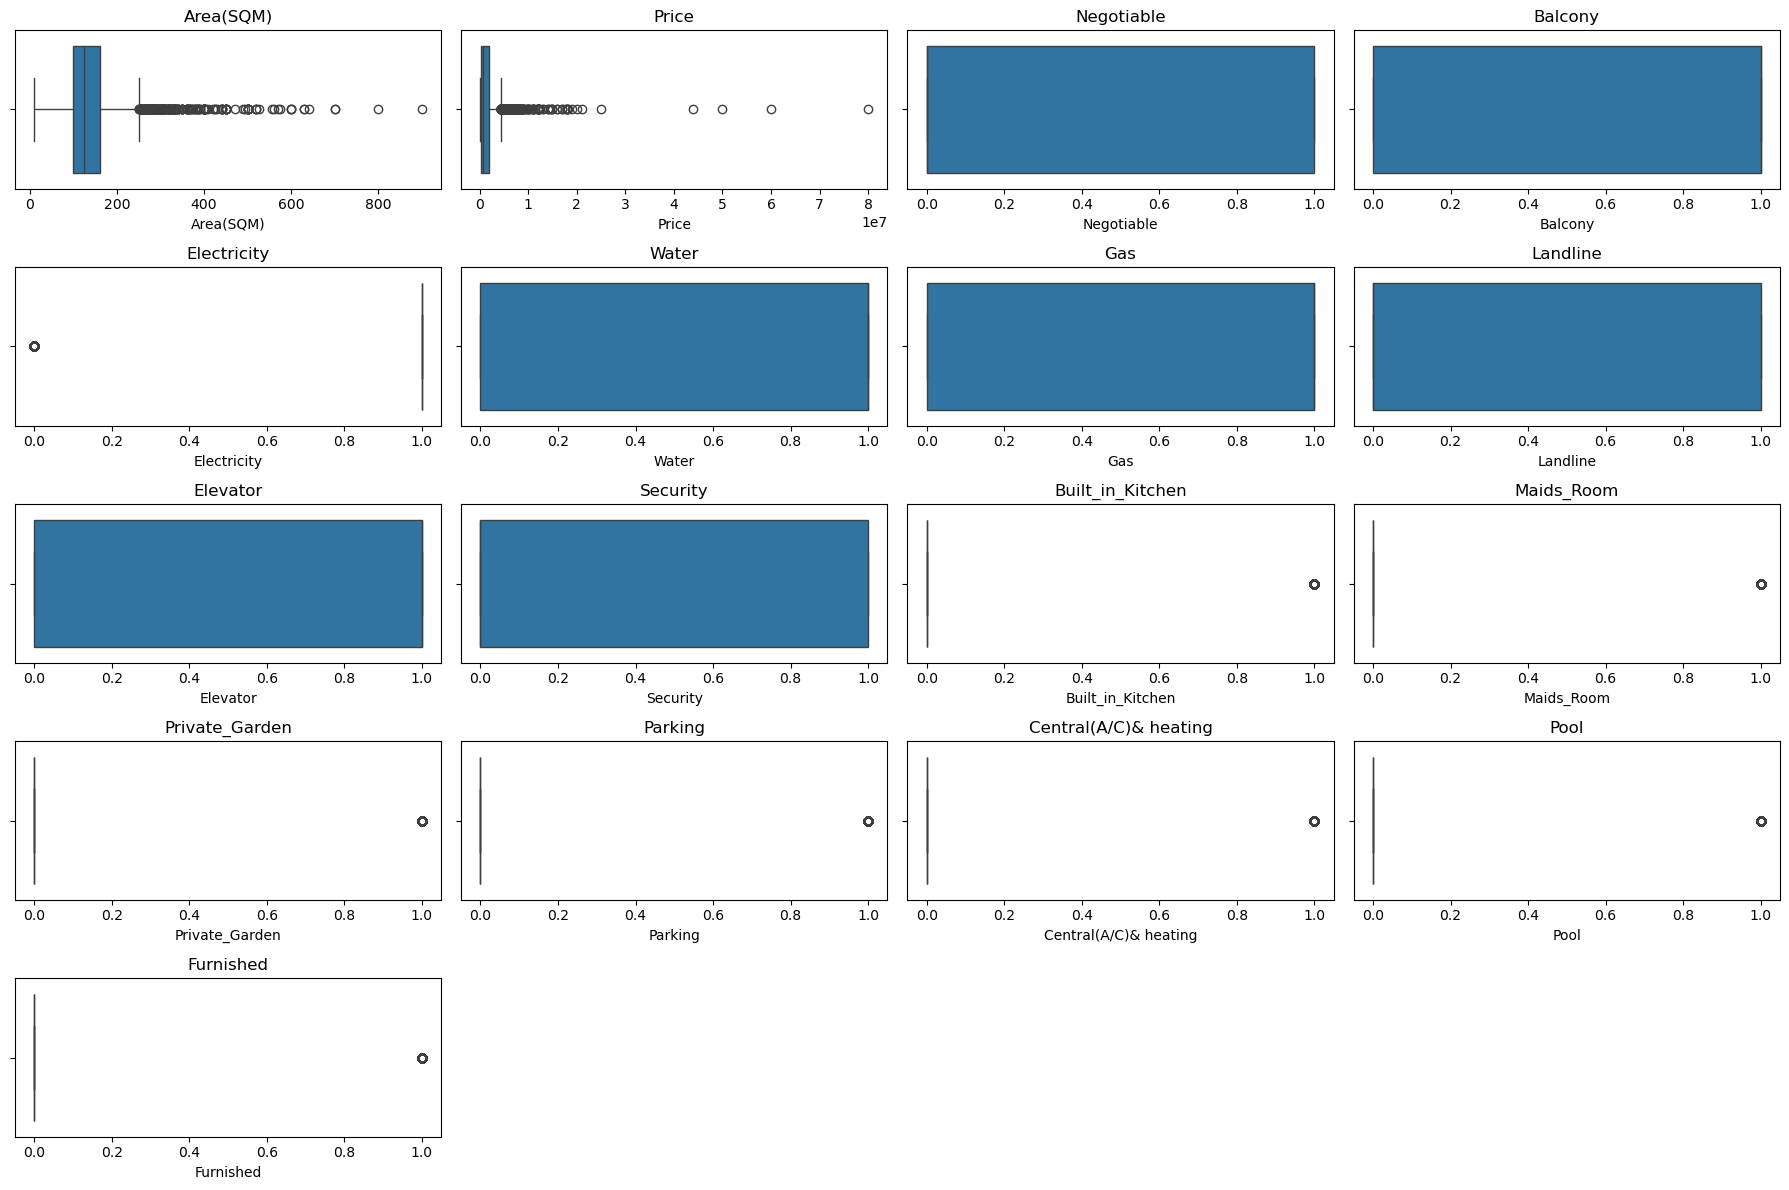

In [8]:
plt.figure(figsize=(18, 12))
for i, col in enumerate(num_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.boxplot(x=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

**Categorical Features Analysis:**

**Location:** 53 unique neighborhoods in Alexandria. Smoha, Nakheel, and Sidi Beshr have the highest listing counts.

**Type:** Apartments dominate (~90%+ of listings), followed by Duplex and Studio. Villas and Penthouses are rare.

**Level:** Most listings are floors 3–6, with '10+' being the most frequent single value representing high-rise buildings.

**Delivery_Term:** Majority are 'Finished' (move-in ready). 'Semi Finished' and 'Core & Shell' represent under-construction units.

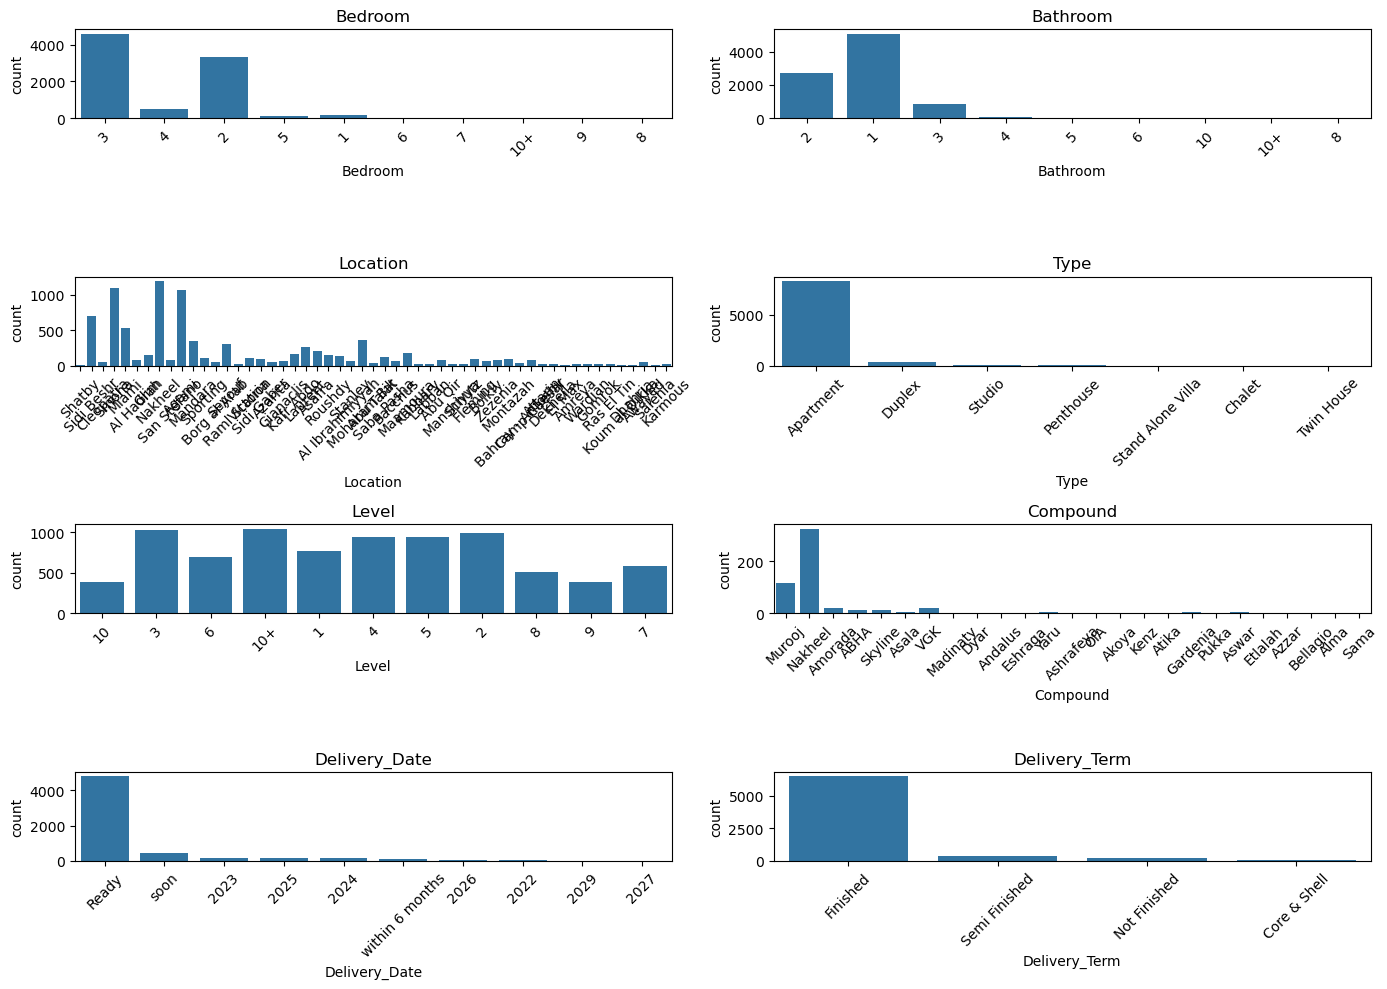

In [9]:
n_cols_plot = 2
n_rows_plot = math.ceil(len(cat_cols) / n_cols_plot)

plt.figure(figsize=(14, 10))
for i, col in enumerate(cat_cols):
    plt.subplot(n_rows_plot, n_cols_plot, i + 1)
    sns.countplot(x=col, data=df)
    plt.xticks(rotation=45)
    plt.title(col)
plt.tight_layout()
plt.show()

**Price Distribution:**

The Price column is heavily right-skewed with a long tail. Most properties are priced below 2M EGP, while a small number of luxury properties reach up to 80M EGP. This skew will be addressed using a log transformation before modeling.

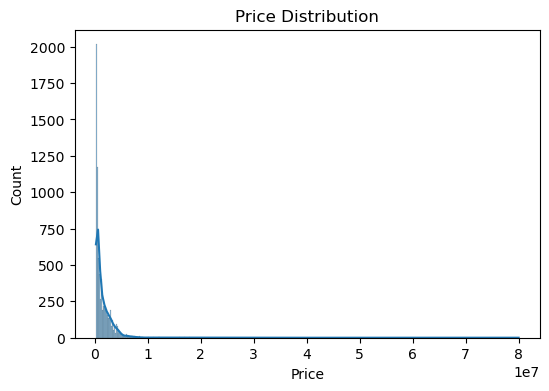

In [10]:
plt.figure(figsize=(6, 4))
sns.histplot(df["Price"], kde=True)
plt.title("Price Distribution")
plt.show()

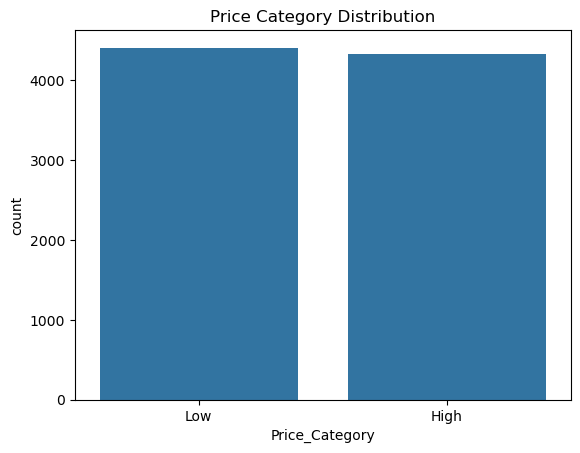

In [11]:
df["Price_Category"] = pd.qcut(df["Price"], q=2, labels=["Low", "High"])

sns.countplot(x="Price_Category", data=df)
plt.title("Price Category Distribution")
plt.show()

In [12]:
df = df.dropna(subset=["Type"])
print(f"Shape after dropping Type null: {df.shape}")

Shape after dropping Type null: (8740, 26)


Dropped rows with missing Type because only one row was missing, and Type is a key property feature.

In [13]:
level_mode = df["Level"].mode()[0]
df["Level"] = df["Level"].fillna(level_mode)
print(f"Level mode used: {level_mode}")

Level mode used: 10+


Filled missing Level with the mode (most frequent value) to preserve dataset size with minimal distortion.

In [14]:
furnished_mode = df["Furnished"].mode()[0]
df["Furnished"] = df["Furnished"].fillna(furnished_mode)
print(f"Furnished mode used: {furnished_mode}")

Furnished mode used: 0.0


Filled missing Furnished with the mode since it is a binary feature and mode is the most stable simple imputation.

In [15]:
df["In_Compound"] = df["Compound"].notna().astype("int")
df = df.drop(columns=["Compound"])
print(df["In_Compound"].value_counts())

In_Compound
0    8202
1     538
Name: count, dtype: int64


Converted Compound into a binary feature (In_Compound) to keep useful information while avoiding sparse high-missing text values.

In [16]:
import numpy as np

def parse_delivery_date(val, ref_year=2024):
    if pd.isna(val):
        return np.nan
    val = str(val).strip().lower()
    if val == "ready":
        return 0
    if val in ["soon", "within 6 months"]:
        return 1
    try:
        return max(int(val) - ref_year, 0)
    except:
        return np.nan

df["years_to_delivery"] = df["Delivery_Date"].apply(parse_delivery_date)
df["delivery_unknown"] = df["years_to_delivery"].isna().astype(int)
df["years_to_delivery"] = df["years_to_delivery"].fillna(0)
df = df.drop(columns=["Delivery_Date"])

Converted Delivery_Date into numeric years_to_delivery for model-friendly representation of delivery time.

In [17]:
term_mode = df["Delivery_Term"].mode()[0]
df["Delivery_Term"] = df["Delivery_Term"].fillna(term_mode)
print(f"Delivery_Term mode: {term_mode}")

Delivery_Term mode: Finished


In [18]:
print("Missing values after treatment:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print(f"Final shape: {df.shape}")

Missing values after treatment:
Series([], dtype: int64)
Final shape: (8740, 27)


Verified no remaining missing values before transformation and encoding steps.

In [19]:
def iqr_info(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    n_out = ((series < lower) | (series > upper)).sum()
    pct_out = n_out / len(series) * 100
    return q1, q3, iqr, lower, upper, n_out, pct_out

In [20]:
for col in ["Area(SQM)", "Price"]:
    q1, q3, iqr, lower, upper, n_out, pct_out = iqr_info(df[col])
    print(f"{col} BEFORE:")
    print(f"  Q1={q1:.2f}, Q3={q3:.2f}, IQR={iqr:.2f}")
    print(f"  Bounds: [{lower:.2f}, {upper:.2f}]")
    print(f"  Outliers: {n_out} ({pct_out:.2f}%)\n")
print("Skewness BEFORE:")
print(f"  Area(SQM): {df['Area(SQM)'].skew():.2f}")
print(f"  Price: {df['Price'].skew():.2f}\n")

Area(SQM) BEFORE:
  Q1=100.00, Q3=160.00, IQR=60.00
  Bounds: [10.00, 250.00]
  Outliers: 450 (5.15%)

Price BEFORE:
  Q1=375000.00, Q3=2000000.00, IQR=1625000.00
  Bounds: [-2062500.00, 4437500.00]
  Outliers: 412 (4.71%)

Skewness BEFORE:
  Area(SQM): 2.45
  Price: 12.91



In [21]:
_, _, _, lower_area, upper_area, _, _ = iqr_info(df["Area(SQM)"])
df["Area(SQM)"] = df["Area(SQM)"].clip(lower=lower_area, upper=upper_area)

df["Price_log"] = np.log1p(df["Price"])

_, _, _, lower_plog, upper_plog, _, _ = iqr_info(df["Price_log"])
df["Price_log"] = df["Price_log"].clip(lower=lower_plog, upper=upper_plog)

In [22]:
q1, q3, iqr, lower, upper, n_out, pct_out = iqr_info(df["Area(SQM)"])
print("Area(SQM) AFTER capping:")
print(f"  Bounds: [{lower:.2f}, {upper:.2f}]")
print(f"  Outliers: {n_out} ({pct_out:.2f}%)")
print(f"  Min={df['Area(SQM)'].min():.2f}, Max={df['Area(SQM)'].max():.2f}\n")
q1, q3, iqr, lower, upper, n_out, pct_out = iqr_info(df["Price_log"])
print("Price_log AFTER transform (+ capping):")
print(f"  Bounds: [{lower:.2f}, {upper:.2f}]")
print(f"  Outliers: {n_out} ({pct_out:.2f}%)")
print(f"  Min={df['Price_log'].min():.2f}, Max={df['Price_log'].max():.2f}\n")
print("Skewness AFTER:")
print(f"  Area(SQM): {df['Area(SQM)'].skew():.2f}")
print(f"  Price_log: {df['Price_log'].skew():.2f}\n")
print(f"Final shape: {df.shape}")

Area(SQM) AFTER capping:
  Bounds: [10.00, 250.00]
  Outliers: 0 (0.00%)
  Min=10.00, Max=250.00

Price_log AFTER transform (+ capping):
  Bounds: [10.32, 17.02]
  Outliers: 0 (0.00%)
  Min=12.21, Max=17.02

Skewness AFTER:
  Area(SQM): 0.82
  Price_log: 0.33

Final shape: (8740, 28)


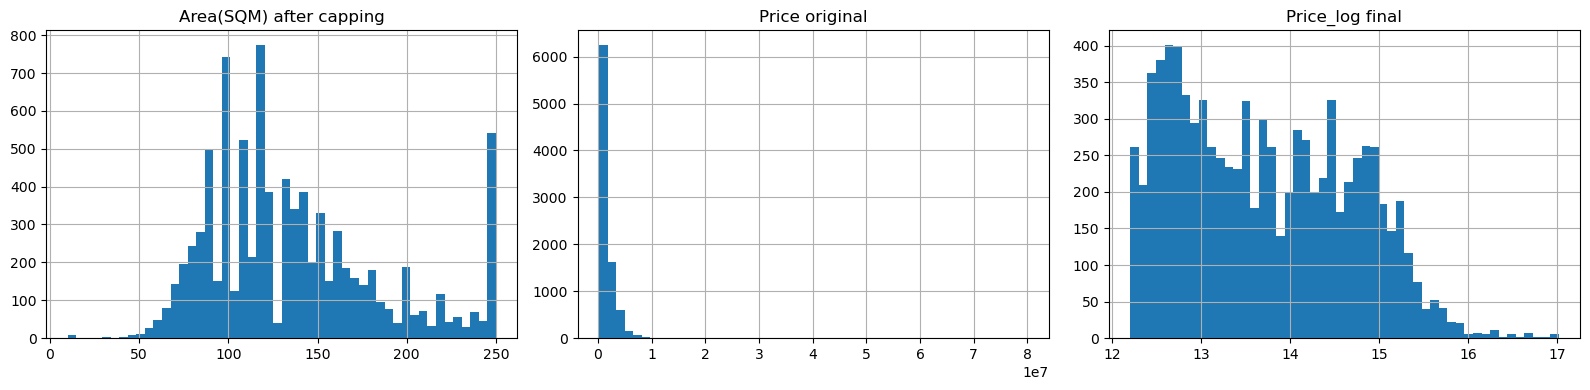

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
df["Area(SQM)"].hist(ax=axes[0], bins=50)
axes[0].set_title("Area(SQM) after capping")
df["Price"].hist(ax=axes[1], bins=50)
axes[1].set_title("Price original")
df["Price_log"].hist(ax=axes[2], bins=50)
axes[2].set_title("Price_log final")
plt.tight_layout()
plt.show()

- Applied IQR capping on Area(SQM) to limit extreme values while keeping all records.
- Applied log1p transformation on Price to reduce strong right skew (skewness: 12.9 → 0.33).
- RobustScaler will be used on continuous features as it is less sensitive to remaining outliers than StandardScaler.

In [24]:
obj_cols = df.select_dtypes(include="object").columns
print("Object columns:", list(obj_cols), "\n")
for col in obj_cols:
    print(f"\n===== {col} =====")
    vals = sorted(df[col].dropna().astype(str).str.strip().unique())
    print("Count unique:", len(vals))
    print("Sample unique values:", vals[:50])

for col in ["Bedroom", "Bathroom", "Level"]:
    if col in df.columns:
        print(f"\n===== Raw value counts: {col} =====")
        print(df[col].astype(str).str.strip().value_counts(dropna=False).head(30))

Object columns: ['Bedroom', 'Bathroom', 'Location', 'Type', 'Level', 'Delivery_Term'] 


===== Bedroom =====
Count unique: 10
Sample unique values: ['1', '10+', '2', '3', '4', '5', '6', '7', '8', '9']

===== Bathroom =====
Count unique: 9
Sample unique values: ['1', '10', '10+', '2', '3', '4', '5', '6', '8']

===== Location =====
Count unique: 53
Sample unique values: ['Abu Qir', 'Abu Talat', 'Agami', 'Al Hadrah', 'Al Ibrahimiyyah', 'Amreya', 'Asafra', 'Attarin', 'Awayed', 'Azarita', 'Bacchus', 'Bahray - Anfoshy', 'Bolkly', 'Borg al-Arab', 'Camp Caesar', 'Cleopatra', 'Dekheila', 'Dhahria', 'El Max', 'Fleming', 'Gianaclis', 'Glim', 'Gomrok', 'Kabbary', 'Kafr Abdo', 'Karmous', 'Koum al-Dikka', 'Labban', 'Laurent', 'Maamoura', 'Mandara', 'Manshiyya', 'Miami', 'Moharam Bik', 'Montazah', 'Nakheel', 'Raml Station', 'Ras El Tin', 'Roushdy', 'Saba Pasha', 'Salehia', 'San Stefano', 'Schutz', 'Seyouf', 'Shatby', 'Sidi Beshr', 'Sidi Gaber', 'Smoha', 'Sporting', 'Stanley']

===== Type =====
Count 

C:\Users\Compu House\AppData\Local\Temp\ipykernel_7012\4160542297.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  obj_cols = df.select_dtypes(include="object").columns


In [25]:
num_like_cols = ["Bedroom", "Bathroom", "Level"]
for col in num_like_cols:
    df[col] = df[col].astype(str).str.strip().replace("10+", "10")
    df[col] = pd.to_numeric(df[col], errors="coerce")

print("NaNs after numeric conversion:")
print(df[num_like_cols].isna().sum())

for col in num_like_cols:
    if df[col].isna().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

print("\nDtypes after conversion:")
print(df[num_like_cols].dtypes)

for col in num_like_cols:
    print(f"\n{col} unique values:", sorted(df[col].dropna().unique())[:20])

NaNs after numeric conversion:
Bedroom     0
Bathroom    0
Level       0
dtype: int64

Dtypes after conversion:
Bedroom     int64
Bathroom    int64
Level       int64
dtype: object

Bedroom unique values: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

Bathroom unique values: [1, 2, 3, 4, 5, 6, 8, 10]

Level unique values: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


In [26]:
from sklearn.preprocessing import RobustScaler

cat_cols_encode = ["Location", "Type", "Delivery_Term"]
df_model = pd.get_dummies(df, columns=cat_cols_encode, drop_first=True, dtype=int)
print("Shape after encoding:", df_model.shape)

scale_cols = ["Area(SQM)", "Bedroom", "Bathroom", "years_to_delivery"]
scale_cols = [c for c in scale_cols if c in df_model.columns]
scaler = RobustScaler()
df_model[scale_cols] = scaler.fit_transform(df_model[scale_cols])
print("Scaled columns:", scale_cols)
print("Final shape:", df_model.shape)

Shape after encoding: (8740, 86)
Scaled columns: ['Area(SQM)', 'Bedroom', 'Bathroom', 'years_to_delivery']
Final shape: (8740, 86)


In [27]:
target_col = "Price_log" if "Price_log" in df_model.columns else "Price"
X = df_model.drop(columns=[target_col])
y = df_model[target_col]

if target_col == "Price_log" and "Price" in X.columns:
    X = X.drop(columns=["Price"])

if "Price_Category" in X.columns:
    X = X.drop(columns=["Price_Category"])

print("Target used:", target_col)
print("X shape:", X.shape)
print("y shape:", y.shape)

Target used: Price_log
X shape: (8740, 83)
y shape: (8740,)


In [28]:
features = df_model.drop(columns=['Cluster', 'Price', 'Price_log', 'Price_Category'], errors='ignore')

**Encoding & Scaling Notes:**
- One-hot encoding for nominal categories (Location, Type, Delivery_Term) — label encoding would impose a false ordering.
- Level was converted to numeric first, then one-hot encoded.
- RobustScaler applied to continuous features.
- **Price_Category was excluded from X** to prevent data leakage (it is derived directly from the target Price).

## Genetic Algorithm — Feature Selection

In [ ]:
!pip install numpy==1.26.4
!pip install scikit-learn-extra==0.3.0

In [30]:
import numpy as np, random, matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
from sklearn_extra.cluster import KMedoids

random.seed(42)
np.random.seed(42)

In [31]:
from sklearn_extra.cluster import KMedoids
from sklearn.metrics import silhouette_score

s_scores = []
K_range = range(2, 6)
X_sample = features.sample(n=500, random_state=42).values

for k in K_range:
    labels = KMedoids(n_clusters=k, metric='manhattan', random_state=42).fit_predict(X_sample)
    s_scores.append(silhouette_score(X_sample, labels, metric='manhattan'))

best_k_ga = list(K_range)[s_scores.index(max(s_scores))]
print(f"Best K for GA = {best_k_ga}")

K_CLUSTERS = best_k_ga

Best K for GA = 2


In [32]:
ga_features = X.copy()
ga_features = ga_features.select_dtypes(include=["number"])

feature_names = list(ga_features.columns)
N = len(feature_names)
X_ga = ga_features.values

print(f"Total features : {N}")
print(f"Total samples  : {X_ga.shape[0]}")

Total features : 83
Total samples  : 8740


### GA Parameters

| Parameter  | Value | Description                               |
| ---------- | ----- | ----------------------------------------- |
| POP        | 30    | Number of chromosomes per generation      |
| GENS       | 30    | Number of generations                     |
| CR         | 0.8   | Crossover probability                     |
| MR         | 0.02  | Mutation probability per gene             |
| K_CLUSTERS | 2     | Number of clusters for fitness evaluation |
| TOURK      | 4     | Tournament size for selection             |
| MINF       | 3     | Minimum number of features per chromosome |

**Chromosome:** binary vector of length N — `1` = include feature, `0` = exclude.

In [33]:

POP, GENS, CR, MR = 30, 30, 0.8, 0.02
K_CLUSTERS = best_k_ga
TOURK, MINF = 4, 3

### Fitness Function

1. Select features where gene = `1`
2. Run K-Medoid clustering (metric=manhattan)
3. Return Silhouette Score as fitness
4. Return `-1` as penalty if fewer than 3 features are selected

In [34]:
def fitness(chrom):
    idx = [i for i, g in enumerate(chrom) if g]
    if len(idx) < MINF:
        return -1.0
    try:
        labels = KMedoids(
            n_clusters=K_CLUSTERS, metric="manhattan", random_state=42
        ).fit_predict(X_ga[:, idx])
        return silhouette_score(X_ga[:, idx], labels, metric="manhattan")
    except:
        return -1.0

### GA Operators

- `new_chrom()` — Create a random binary chromosome
- `select()` — Tournament Selection
- `crossover()` — Single-Point Crossover
- `mutate()` — Bit-flip Mutation (2% per gene)

In [35]:
def new_chrom():
    c = [random.randint(0, 1) for _ in range(N)]
    if sum(c) < MINF:
        for i in random.sample(range(N), MINF):
            c[i] = 1
    return c

def select(pop, fits):
    ids = random.sample(range(len(pop)), TOURK)
    return pop[max(ids, key=lambda i: fits[i])][:]

def crossover(p1, p2):
    if random.random() > CR:
        return p1[:], p2[:]
    pt = random.randint(1, N - 1)
    return p1[:pt] + p2[pt:], p2[:pt] + p1[pt:]

def mutate(c):
    c = [1 - g if random.random() < MR else g for g in c]
    if sum(c) < MINF:
        zeros = [i for i, g in enumerate(c) if not g]
        for i in random.sample(zeros, MINF - sum(c)):
            c[i] = 1
    return c

In [36]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

labels_all = KMedoids(
    n_clusters=K_CLUSTERS, metric="manhattan", random_state=42
).fit_predict(X_ga)
baseline_all = silhouette_score(X_ga, labels_all, metric="manhattan")
print(f"Silhouette (all {N} features) : {baseline_all:.4f}  (baseline)")

pop = [new_chrom() for _ in range(POP)]

Silhouette (all 83 features) : 0.1049  (baseline)


### Evolution Loop

Each generation: evaluate fitness → elitism → selection → crossover → mutation.

In [37]:
best_hist, avg_hist = [], []
best_chrom, best_score = None, -1.0

for gen in range(GENS):
    fits = [fitness(c) for c in pop]
    bi = int(np.argmax(fits))

    best_hist.append(fits[bi])
    avg_hist.append(np.mean(fits))

    if fits[bi] > best_score:
        best_score, best_chrom = fits[bi], pop[bi][:]

    next_pop = [pop[bi][:]]
    while len(next_pop) < POP:
        c1, c2 = crossover(select(pop, fits), select(pop, fits))
        next_pop += [mutate(c1), mutate(c2)]
    pop = next_pop[:POP]

    if (gen + 1) % 5 == 0:
        print(f"Gen {gen+1:3d} | Best: {fits[bi]:.4f} | Avg: {np.mean(fits):.4f}")

Gen   5 | Best: 0.3709 | Avg: 0.0880
Gen  10 | Best: 0.3964 | Avg: -0.0307
Gen  15 | Best: 0.4044 | Avg: 0.2066
Gen  20 | Best: 0.4151 | Avg: 0.1680
Gen  25 | Best: 0.4184 | Avg: 0.0359
Gen  30 | Best: 0.4505 | Avg: 0.3416


In [38]:
selected = [feature_names[i] for i, g in enumerate(best_chrom) if g]
improvement = (best_score - baseline_all) / abs(baseline_all) * 100

print(f"{'='*52}")
print(f"Silhouette — All {N} features  : {baseline_all:.4f}")
print(f"Silhouette — GA {len(selected)} features   : {best_score:.4f}")
print(f"Improvement                     : {improvement:+.2f}%")
print(f"\nSelected Features ({len(selected)}):")
for f in selected:
    print(f"  - {f}")
print("=" * 52)

Silhouette — All 83 features  : 0.1049
Silhouette — GA 27 features   : 0.4505
Improvement                     : +329.54%

Selected Features (27):
  - Area(SQM)
  - Balcony
  - Gas
  - Landline
  - Built_in_Kitchen
  - Private_Garden
  - Level
  - Location_Abu Talat
  - Location_Al Hadrah
  - Location_Al Ibrahimiyyah
  - Location_Amreya
  - Location_Azarita
  - Location_Borg al-Arab
  - Location_Camp Caesar
  - Location_Dhahria
  - Location_El Max
  - Location_Glim
  - Location_Kabbary
  - Location_Karmous
  - Location_Manshiyya
  - Location_Ras El Tin
  - Location_Roushdy
  - Location_San Stefano
  - Location_Sidi Gaber
  - Type_Chalet
  - Type_Stand Alone Villa
  - Type_Twin House


In [39]:
X_selected = X[selected].copy()
print(f"X_selected shape: {X_selected.shape}")
print(f"Features: {len(selected)} out of {N}")

X_selected shape: (8740, 27)
Features: 27 out of 83


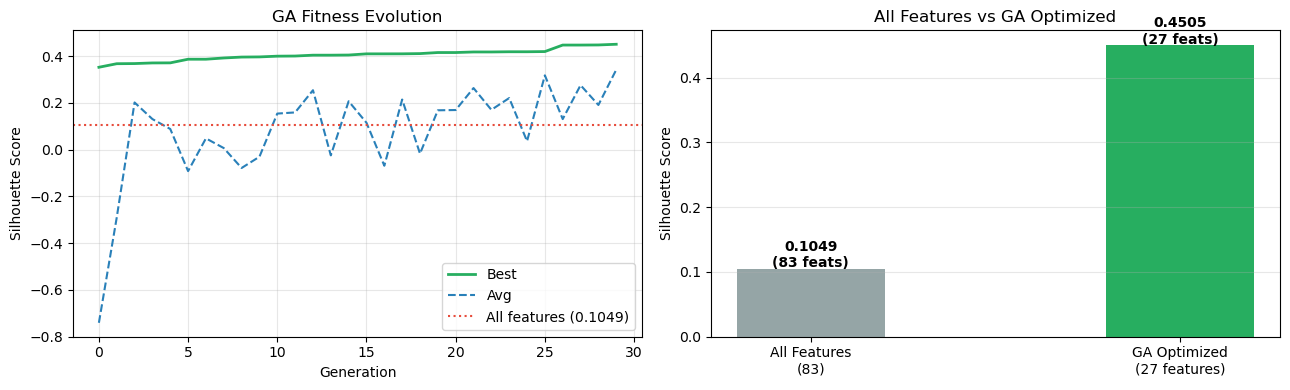

In [40]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(best_hist, color="#27ae60", linewidth=2, label="Best")
ax1.plot(avg_hist, color="#2980b9", linewidth=1.5, linestyle="--", label="Avg")
ax1.axhline(baseline_all, color="#e74c3c", linestyle=":",
            label=f"All features ({baseline_all:.4f})")
ax1.set(xlabel="Generation", ylabel="Silhouette Score", title="GA Fitness Evolution")
ax1.legend()
ax1.grid(alpha=0.3)

bars = ax2.bar(
    [f"All Features\n({N})", f"GA Optimized\n({len(selected)} features)"],
    [baseline_all, best_score],
    color=["#95a5a6", "#27ae60"], width=0.4,
)
for bar, v, n in zip(bars, [baseline_all, best_score], [N, len(selected)]):
    ax2.text(bar.get_x() + bar.get_width() / 2, v + 0.002,
             f"{v:.4f}\n({n} feats)", ha="center", fontsize=10, fontweight="bold")
ax2.set(ylabel="Silhouette Score", title="All Features vs GA Optimized")
ax2.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("task6_ga.png", dpi=150, bbox_inches="tight")
plt.show()

## TASK 3 — Hierarchical Clustering Using GA-selected features (X_selected)

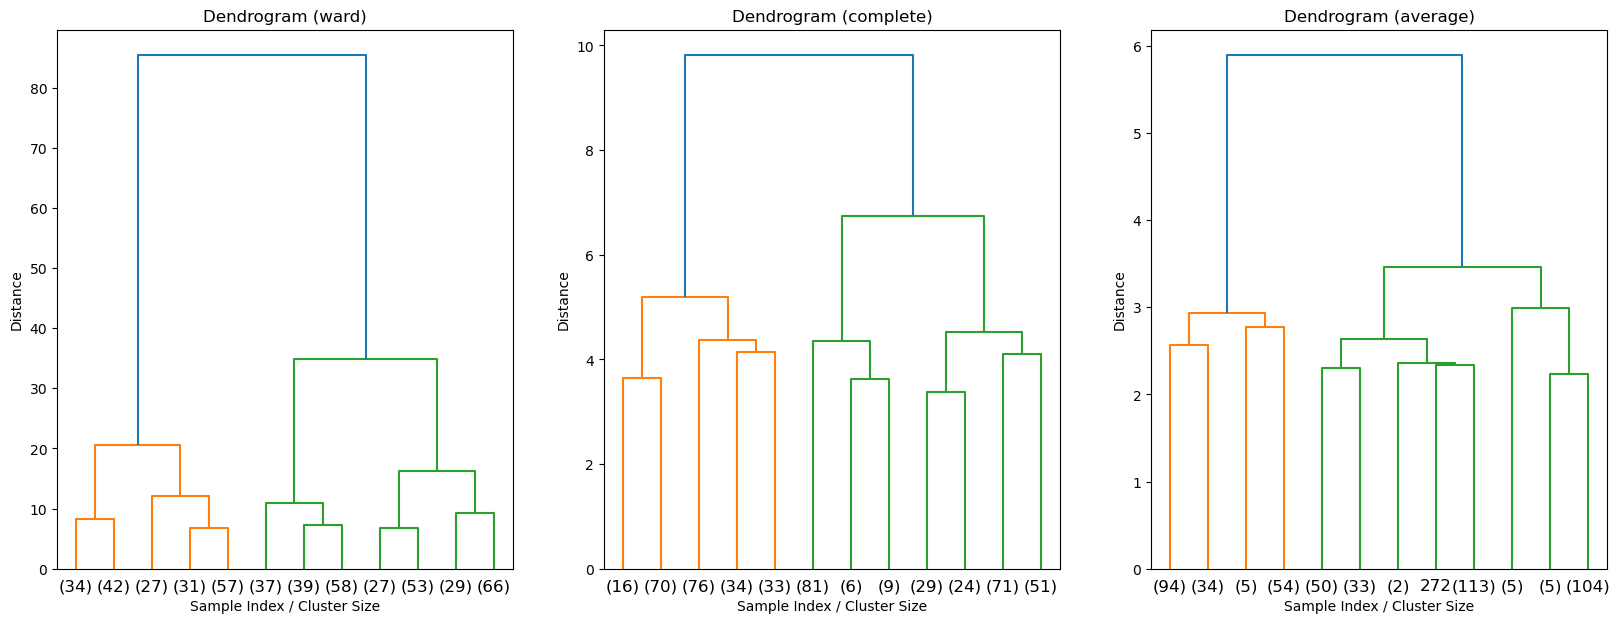

In [41]:

import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering

X_hier = X_selected.copy()
X_hier_sample = X_hier.sample(n=500, random_state=42) if len(X_hier) > 500 else X_hier

methods = ["ward", "complete", "average"]

plt.figure(figsize=(20, 7))
for i, method in enumerate(methods):
    plt.subplot(1, 3, i + 1)
    linkage_matrix = sch.linkage(X_hier_sample, method=method)
    sch.dendrogram(linkage_matrix, truncate_mode="lastp", p=12)
    plt.title(f"Dendrogram ({method})")
    plt.xlabel("Sample Index / Cluster Size")
    plt.ylabel("Distance")
plt.show()

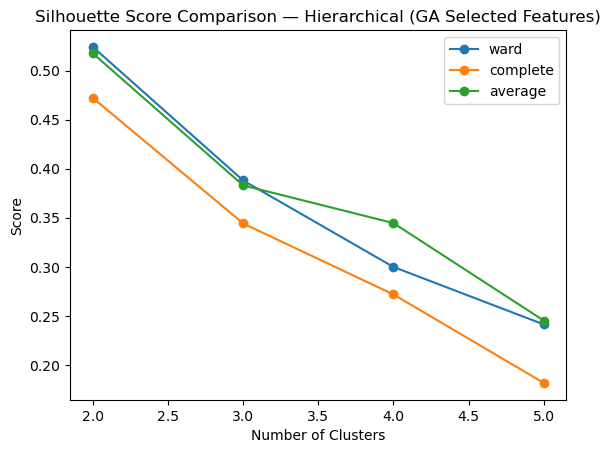

In [42]:
K_range = range(2, 6)
results = {}

for method in methods:
    scores = []
    for k in K_range:
        model = AgglomerativeClustering(n_clusters=k, linkage=method)
        labels = model.fit_predict(X_hier_sample)
        score = silhouette_score(X_hier_sample, labels)
        scores.append(score)
    results[method] = scores

for method in methods:
    plt.plot(K_range, results[method], marker="o", label=method)

plt.title("Silhouette Score Comparison — Hierarchical (GA Selected Features)")
plt.xlabel("Number of Clusters")
plt.ylabel("Score")
plt.legend()
plt.show()

In [43]:
final_model = AgglomerativeClustering(n_clusters=2, linkage='ward')
df['Cluster'] = final_model.fit_predict(X_hier)
profile = df.groupby("Cluster")[["Price", "Area(SQM)", "Bedroom", "Bathroom"]].mean()
print(profile)

                Price   Area(SQM)   Bedroom  Bathroom
Cluster                                              
0        1.386289e+06  135.489401  2.643134  1.523502
1        1.608474e+06  139.948115  2.734238  1.575264


## Task 4: K-Medoid Clustering

Using GA-selected features (X_selected).

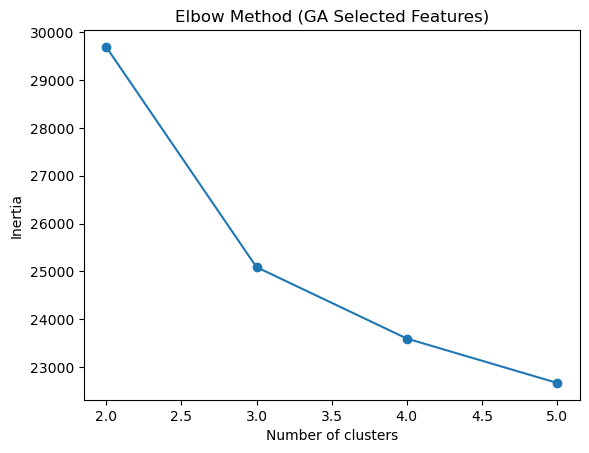

In [44]:
X_kmed = X_selected.copy()

inertia = []
for k in range(2, 6):
    model = KMedoids(n_clusters=k, metric="manhattan", random_state=42)
    model.fit(X_kmed)
    inertia.append(model.inertia_)

plt.plot(range(2, 6), inertia, marker="o")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method (GA Selected Features)")
plt.show()

k = 2, Silhouette Score = 0.4505
k = 3, Silhouette Score = 0.3620
k = 4, Silhouette Score = 0.2714
k = 5, Silhouette Score = 0.2034


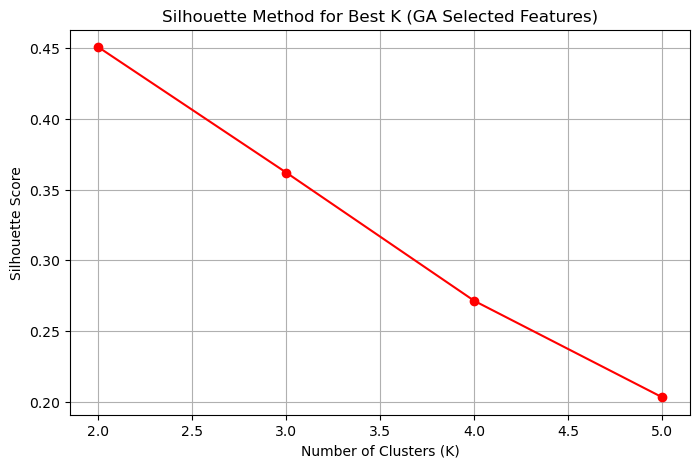

In [45]:
s_scores = []
for k in K_range:
    kmedoids = KMedoids(n_clusters=k, metric="manhattan", random_state=42)
    labels = kmedoids.fit_predict(X_kmed)

    if len(np.unique(labels)) > 1:
        score = silhouette_score(X_kmed, labels, metric="manhattan")
    else:
        score = 0.0
    s_scores.append(score)
    print(f"k = {k}, Silhouette Score = {score:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(K_range, s_scores, marker="o", color="red")
plt.title("Silhouette Method for Best K (GA Selected Features)")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

In [46]:
best_k = list(K_range)[s_scores.index(max(s_scores))]
print(f"Best K = {best_k}")

kmedoids_final = KMedoids(n_clusters=best_k, metric="manhattan", random_state=42)
kmedoids_final.fit(X_kmed)
df["KMedoids_Cluster"] = kmedoids_final.labels_

score = silhouette_score(X_kmed, kmedoids_final.labels_, metric="manhattan")
print(f"Silhouette Score (GA selected features): {score:.4f}")

profile = df.groupby("KMedoids_Cluster")[["Price", "Area(SQM)", "Bedroom", "Bathroom"]].mean()
print(profile)

Best K = 2
Silhouette Score (GA selected features): 0.4505
                         Price   Area(SQM)   Bedroom  Bathroom
KMedoids_Cluster                                              
0                 1.340748e+06  133.786934  2.630846  1.500928
1                 1.679223e+06  142.635442  2.752983  1.610979


In [47]:
profile = df.groupby("KMedoids_Cluster")[["Price", "Area(SQM)", "Bedroom", "Bathroom"]].mean()
print(profile.T)

KMedoids_Cluster             0             1
Price             1.340748e+06  1.679223e+06
Area(SQM)         1.337869e+02  1.426354e+02
Bedroom           2.630846e+00  2.752983e+00
Bathroom          1.500928e+00  1.610979e+00


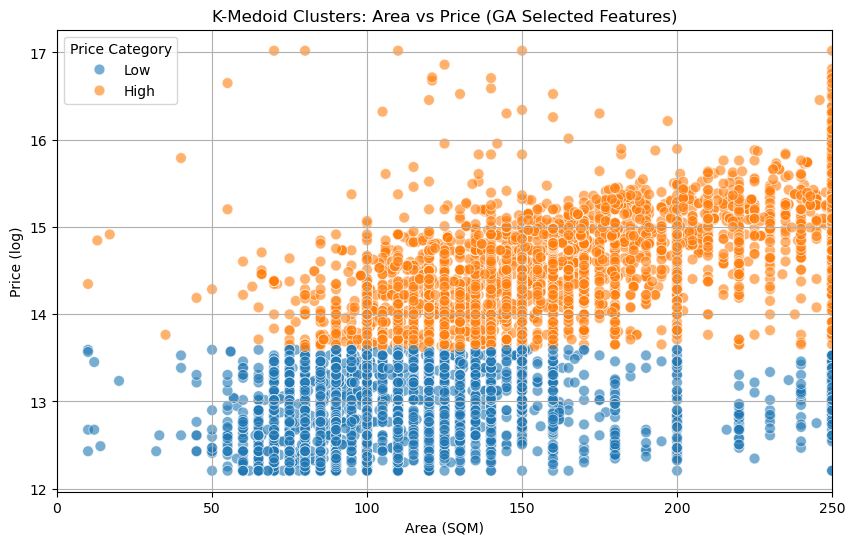

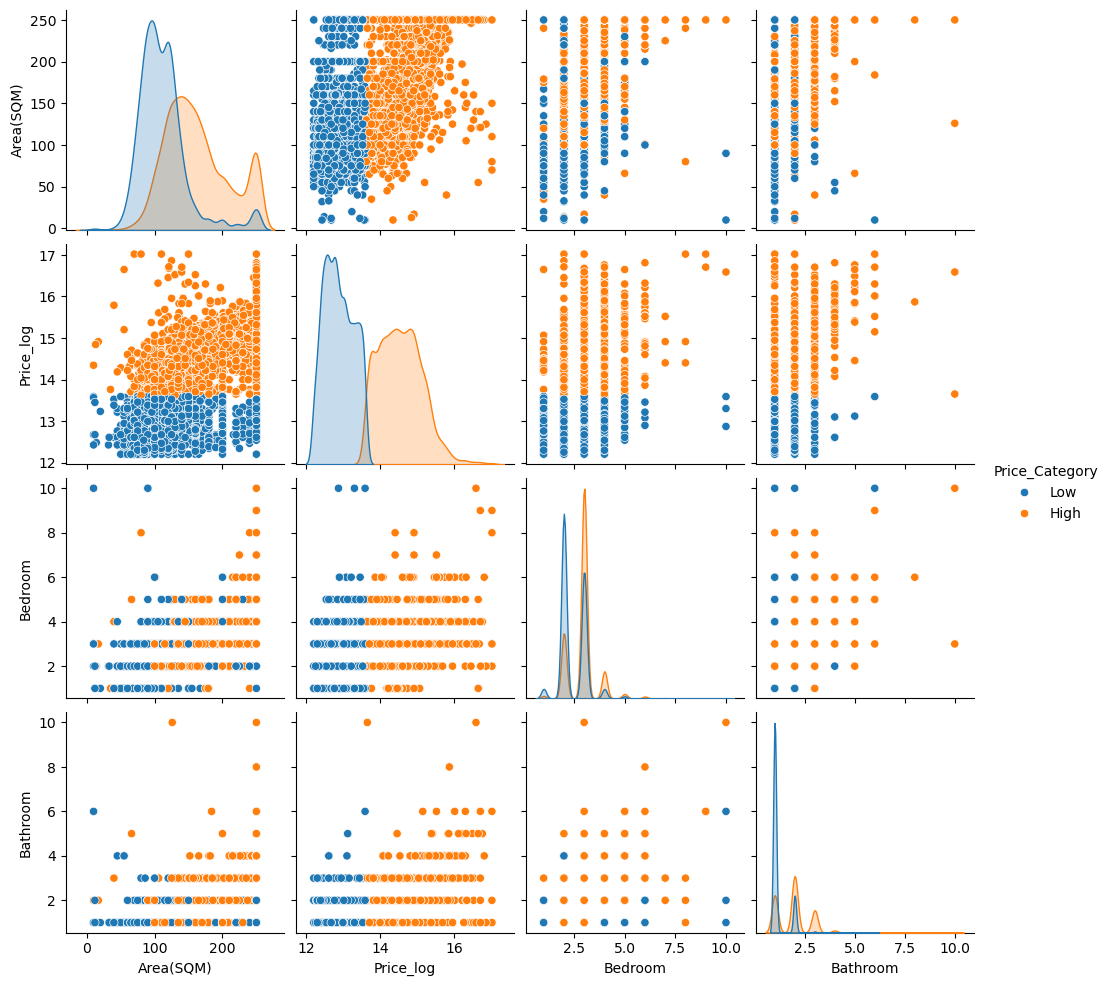

In [48]:
df_plot = df[df["Price_Category"].isin(["Low", "High"])]

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=df_plot["Area(SQM)"], y=df_plot["Price_log"],
    hue="Price_Category",
    data=df_plot,
    palette="tab10", alpha=0.6, s=60,
)
plt.title("K-Medoid Clusters: Area vs Price (GA Selected Features)")
plt.xlabel("Area (SQM)")
plt.ylabel("Price (log)")
plt.xlim(0, 250)
plt.legend(title="Price Category")
plt.grid(True)
plt.show()

sns.pairplot(
    df_plot,
    vars=["Area(SQM)", "Price_log", "Bedroom", "Bathroom"],
    hue="Price_Category",
    palette="tab10",
)
plt.show()

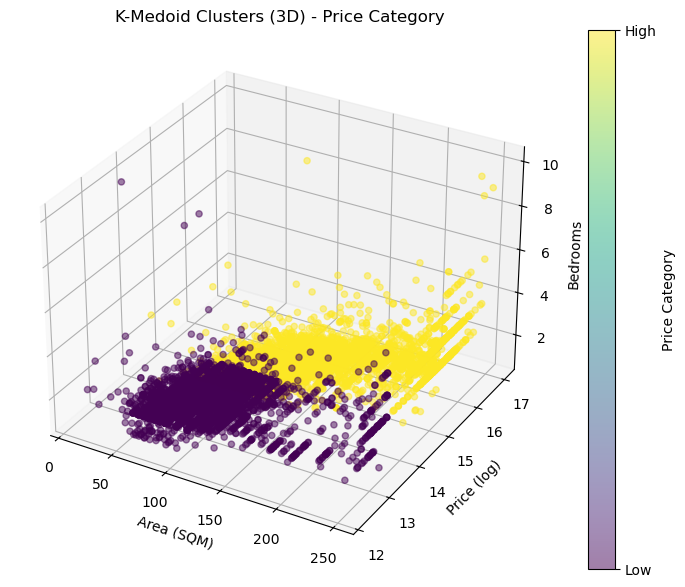

In [49]:
category_map = {"Low": 0, "High": 1}
df["Price_Category_num"] = df["Price_Category"].map(category_map)

df_plot = df[df["Price_Category"].isin(["Low", "High"])]

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(
    df_plot["Area(SQM)"],
    df_plot["Price_log"],
    df_plot["Bedroom"],
    c=df_plot["Price_Category_num"],
    cmap="viridis",
    alpha=0.5,
    s=20
)

colorbar = plt.colorbar(sc, ax=ax)
colorbar.set_ticks([0, 1])
colorbar.set_ticklabels(["Low", "High"])
colorbar.set_label("Price Category")

ax.set_xlabel("Area (SQM)")
ax.set_ylabel("Price (log)")
ax.set_zlabel("Bedrooms")
plt.title("K-Medoid Clusters (3D) - Price Category")
plt.show()

## Task 5: Fuzzy Logic Inference System

**Input:** Area (SQM), Bathroom count, KMedoids Cluster  
**Output:** Estimated Price (EGP)

In [50]:
#!pip install scikit-fuzzy

In [51]:
import skfuzzy as fuzz
from skfuzzy import control as ctrl

area = ctrl.Antecedent(
    np.arange(df["Area(SQM)"].min(), df["Area(SQM)"].max() + 1, 1), "area"
)
bathroom = ctrl.Antecedent(np.arange(1, 11, 0.1), "bathroom")
cluster = ctrl.Antecedent(np.arange(0, best_k, 0.1), "cluster")

price_category = ctrl.Consequent(np.arange(0, 2, 0.1), 'price_category')
price_category['low']  = fuzz.trimf(price_category.universe, [0, 0, 1])
price_category['high'] = fuzz.trimf(price_category.universe, [0, 1, 1])

a_min, a_max = df["Area(SQM)"].min(), df["Area(SQM)"].max()
a_step = (a_max - a_min) / 2
a_ov = a_step * 0.3

area["small"] = fuzz.trimf(area.universe, [a_min, a_min, a_min + a_step + a_ov])
area["large"] = fuzz.trimf(area.universe, [a_min + a_step - a_ov, a_max, a_max])

bathroom["few"]  = fuzz.trimf(bathroom.universe, [1, 1, 3])
bathroom["many"] = fuzz.trimf(bathroom.universe, [2, 5, 10])

c_max = best_k - 1
cluster["budget"] = fuzz.trimf(cluster.universe, [0, 0, c_max])
cluster["premium"] = fuzz.trimf(cluster.universe, [0, c_max, c_max])

In [52]:
rule1  = ctrl.Rule(area["large"]  & cluster["premium"],              price_category["high"])
rule2  = ctrl.Rule(area["large"]  & cluster["budget"],               price_category["low"])
rule3  = ctrl.Rule(area["small"]  & cluster["premium"],              price_category["low"])
rule4  = ctrl.Rule(area["small"]  & cluster["budget"],               price_category["low"])
rule5  = ctrl.Rule(bathroom["many"] & cluster["premium"],            price_category["high"])
rule6  = ctrl.Rule(bathroom["few"]  & cluster["budget"],             price_category["low"])
rule7  = ctrl.Rule(area["large"]  & bathroom["many"],                price_category["high"])
rule8  = ctrl.Rule(area["large"]  & bathroom["few"],                 price_category["low"])
rule9  = ctrl.Rule(area["small"]  & bathroom["many"],                price_category["low"])
rule10 = ctrl.Rule(area["small"]  & bathroom["few"],                 price_category["low"])
rule11 = ctrl.Rule(cluster["premium"] & bathroom["many"],            price_category["high"])
rule12 = ctrl.Rule(cluster["budget"]  & bathroom["few"],             price_category["low"])
rule13 = ctrl.Rule(area["large"]  & cluster["premium"] & bathroom["many"], price_category["high"])
rule14 = ctrl.Rule(area["large"]  & cluster["premium"] & bathroom["few"],  price_category["high"])
rule15 = ctrl.Rule(area["large"]  & cluster["budget"]  & bathroom["many"], price_category["low"])
rule16 = ctrl.Rule(area["large"]  & cluster["budget"]  & bathroom["few"],  price_category["low"])
rule17 = ctrl.Rule(area["small"]  & cluster["premium"] & bathroom["many"], price_category["low"])
rule18 = ctrl.Rule(area["small"]  & cluster["premium"] & bathroom["few"],  price_category["low"])
rule19 = ctrl.Rule(area["small"]  & cluster["budget"]  & bathroom["many"], price_category["low"])
rule20 = ctrl.Rule(area["small"]  & cluster["budget"]  & bathroom["few"],  price_category["low"])
rule21 = ctrl.Rule(cluster["premium"],                               price_category["high"])
rule22 = ctrl.Rule(cluster["budget"],                                price_category["low"])
rule23 = ctrl.Rule(area["large"],                                    price_category["high"])
rule24 = ctrl.Rule(area["small"],                                    price_category["low"])
rule25 = ctrl.Rule(bathroom["many"],                                 price_category["high"])
rule26 = ctrl.Rule(bathroom["few"],                                  price_category["low"])

price_system = ctrl.ControlSystem([
    rule1,  rule2,  rule3,  rule4,  rule5,  rule6,
    rule7,  rule8,  rule9,  rule10, rule11, rule12,
    rule13, rule14, rule15, rule16, rule17, rule18,
    rule19, rule20, rule21, rule22, rule23, rule24,
    rule25, rule26
])
price_sim = ctrl.ControlSystemSimulation(price_system)

In [53]:
price_sim.input["area"]     = 120
price_sim.input["bathroom"] = 2
price_sim.input["cluster"]  = 1

price_sim.compute()

crisp_category = price_sim.output["price_category"]
print(f"Price Category Score: {crisp_category:.4f}")

low_deg  = fuzz.interp_membership(price_category.universe, price_category["low"].mf,  crisp_category)
high_deg = fuzz.interp_membership(price_category.universe, price_category["high"].mf, crisp_category)

if high_deg > low_deg:
    category = "High"
else:
    category = "Low"

print(f"Price Category: {category}")
print(f"Low  : {low_deg*100:.2f}%")
print(f"High : {high_deg*100:.2f}%")

Price Category Score: 0.6012
Price Category: High
Low  : 39.88%
High : 60.12%


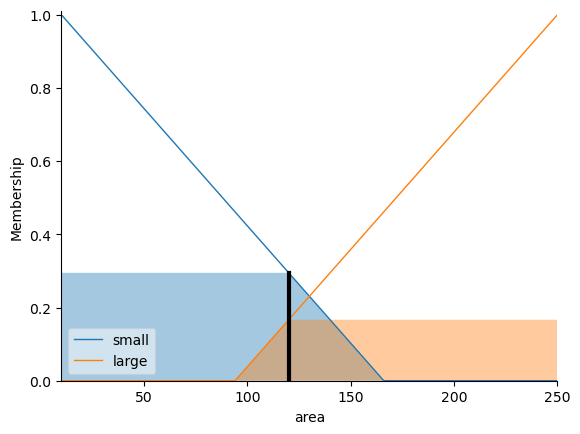

In [54]:
area.view(price_sim)

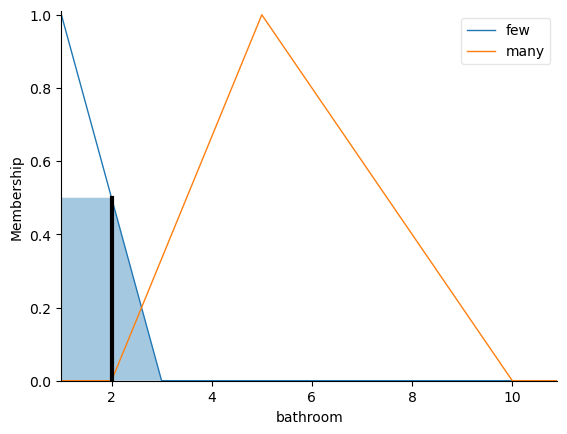

In [55]:
bathroom.view(price_sim)

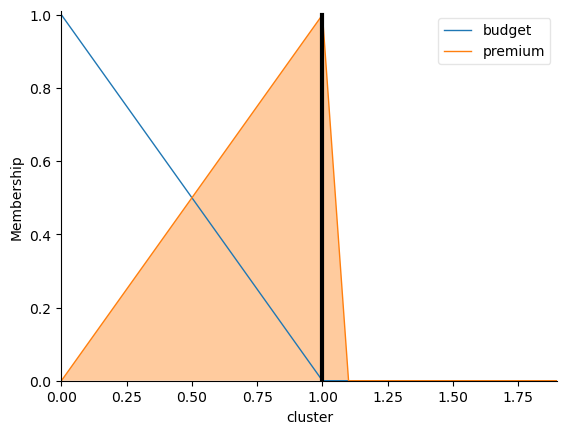

In [56]:
cluster.view(price_sim)

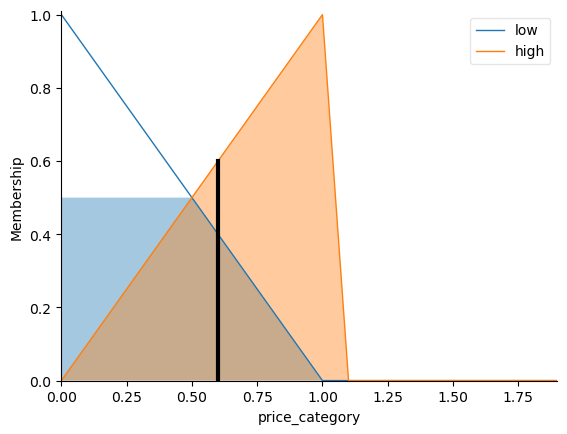

In [57]:
price_category.view(price_sim)


In [58]:
validation_samples = df[["Area(SQM)", "Bathroom", "KMedoids_Cluster", "Price_Category"]].sample(
    5, random_state=42
)

print(f"{'Area':>8} {'Bath':>6} {'Cluster':>8} {'Actual Category':>16} {'Fuzzy Category':>15}")
print("=" * 60)

for _, row in validation_samples.iterrows():
    price_sim.input["area"]     = row["Area(SQM)"]
    price_sim.input["bathroom"] = row["Bathroom"]
    price_sim.input["cluster"]  = int(row["KMedoids_Cluster"])
    price_sim.compute()

    crisp_category = price_sim.output["price_category"]

    low_deg  = fuzz.interp_membership(price_category.universe, price_category["low"].mf,  crisp_category)
    high_deg = fuzz.interp_membership(price_category.universe, price_category["high"].mf, crisp_category)

    if high_deg > low_deg:
        fuzzy_cat = "High"
    else:
        fuzzy_cat = "Low"
        
    print(
        f"{row['Area(SQM)']:>8.1f} {row['Bathroom']:>6.0f} {int(row['KMedoids_Cluster']):>8} "
        f"{str(row['Price_Category']):>16} {fuzzy_cat:>15}"
    )

    Area   Bath  Cluster  Actual Category  Fuzzy Category
   110.0      1        1             High            High
   110.0      1        0              Low             Low
   210.0      3        1             High            High
   135.0      3        0             High             Low
   180.0      1        0             High             Low


In [60]:
!pip install streamlit pyngrok

   ---------------------------------------- 0.0/9.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.1 MB ? eta -:--:--
   - -----------------------------

In [64]:
from pyngrok import ngrok
ngrok.set_auth_token("3CwlKGbAiLZWtzYlJEZH4FrDaUy_5AWVaLDAeViRA8czZTP9G")

import subprocess, time
process = subprocess.Popen(['streamlit', 'run', 'app.py'])
time.sleep(5)

print(ngrok.connect(8501))

NgrokTunnel: "https://swore-stench-unglue.ngrok-free.dev" -> "http://localhost:8501"


t=2026-04-28T18:11:38+0300 lvl=warn msg="failed to open private leg" id=676c7f41f0ac privaddr=localhost:8501 err="dial tcp [::1]:8501: connectex: No connection could be made because the target machine actively refused it."
